# 1. INSTALL & IMPORT

In [15]:
#!pip install sastrawi transformers torch scikit-learn seaborn

import pandas as pd
import numpy as np
import re
import torch
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight


# 2. LOAD DATA

In [16]:
df = pd.read_csv('/content/hasil_auto_labeling (2).csv')
df = df[['text','label']].dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1200 non-null   object
 1   label   1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB


**CEK DISTRIBUSI LABEL**

In [ ]:
print(df['label'].value_counts())

label
netral        405
kritik        327
pertanyaan    286
pujian        129
saran          53
Name: count, dtype: int64


# 3. PREPROCESSING

**HAPUS DUPLIKAT**

In [17]:
df.drop_duplicates(subset ="text", keep = 'first', inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1193 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1193 non-null   object
 1   label   1193 non-null   object
dtypes: object(2)
memory usage: 28.0+ KB


**BERSIHKAN TEKS**

In [18]:
def clean_text(text):
    text = text.lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # hapus angka (opsional)
    text = re.sub(r'\d+', '', text)

    # hapus karakter aneh (TAPI JANGAN HAPUS SEMUA)
    text = re.sub(r'[^\w\s!?]', '', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['bersih'] = df['text'].astype(str).apply(clean_text)

In [19]:
def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text

df['clean'] = df['bersih'].apply(case_folding)

# 4. AUGMENTASI

In [35]:
def augment(text):
    words = text.split()

    if len(words) > 3:
        i = random.randint(0, len(words)-1)

        if random.random() > 0.5:
            words[i] = words[i] + " " + words[i]
        else:
            j = random.randint(0, len(words)-1)
            words[i], words[j] = words[j], words[i]

    return " ".join(words)

df_aug = df.copy()
df_aug['clean'] = df_aug['clean'].apply(augment)

df = pd.concat([df, df_aug])
print(df['label'].value_counts())

label
netral        1596
kritik        1308
pertanyaan    1140
pujian         516
saran          212
Name: count, dtype: int64


# 5. LABEL ENCODING

In [21]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# 6. SPLIT

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'],
    df['label_enc'],
    test_size=0.2,
    stratify=df['label_enc'],
    random_state=42
)

# 7. CLASS WEIGHT

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# 8. TOKENIZER (CNN & BiLSTM)

**TOKENIZER MANUAL (KERAS)**

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 30000
max_len = 120

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)


# 9. EARLY STOPPING

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# 10. MODEL RNN

In [26]:
from tensorflow.keras.layers import *

rnn_model = tf.keras.Sequential([
    Embedding(30000, 128, input_length=120),

    SpatialDropout1D(0.3),

    SimpleRNN(128), # Changed to SimpleRNN
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop]
)

rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)
rnn_acc = accuracy_score(y_test, rnn_pred)

print("=== RNN ===")
print(classification_report(y_test, rnn_pred, target_names=le.classes_))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.2999 - loss: 1.5824 - val_accuracy: 0.3298 - val_loss: 1.5073
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4228 - loss: 1.4400 - val_accuracy: 0.4450 - val_loss: 1.3678
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4834 - loss: 1.2844 - val_accuracy: 0.4555 - val_loss: 1.3018
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6121 - loss: 1.0192 - val_accuracy: 0.5550 - val_loss: 1.1659
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7187 - loss: 0.7691 - val_accuracy: 0.5864 - val_loss: 1.0959
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8066 - loss: 0.5514 - val_accuracy: 0.6178 - val_loss: 0.9569
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9033 - loss: 0.3393 - val_accuracy: 0.6911 - val_loss: 0.9557
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9179 - loss: 0.2453 - val_accuracy: 0.6911 - val_loss: 0

# 11. MODEL BiLSTM

In [11]:
from tensorflow.keras.layers import *

bilstm_model = tf.keras.Sequential([
    Embedding(30000, 128, input_length=120), # Changed input_length to 120 for consistency

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(64)),  # 🔥 cukup 1 layer

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

bilstm_pred = np.argmax(bilstm_model.predict(X_test_pad), axis=1)
bilstm_acc = accuracy_score(y_test, bilstm_pred)

print("=== BiLSTM ===")
print(classification_report(y_test, bilstm_pred, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.3162 - loss: 1.5361 - val_accuracy: 0.2932 - val_loss: 1.4543
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3896 - loss: 1.3975 - val_accuracy: 0.4503 - val_loss: 1.3891
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4619 - loss: 1.3377 - val_accuracy: 0.4869 - val_loss: 1.2932
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4863 - loss: 1.2842 - val_accuracy: 0.4869 - val_loss: 1.2924
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5166 - loss: 1.2298 - val_accuracy: 0.4974 - val_loss: 1.2382
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5364 - loss: 1.1815 - val_accuracy: 0.5236 - val_loss: 1.1992
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5923 - loss: 1.0922 - val_accuracy: 0.5864 - val_loss: 1.1156
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6634 - loss: 0.9428 - val_accuracy: 0.6021 - 

# 12. MODEL INDOBERT

In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

model_name = "indobenchmark/indobert-base-p1"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer_bert(
            list(texts),
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
bert_model.to(device)

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

for epoch in range(3):
    bert_model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} selesai")

bert_model.eval()

bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        pred = torch.argmax(outputs.logits, dim=1)
        bert_preds.extend(pred.cpu().numpy())

bert_acc = accuracy_score(y_test, bert_preds)

print("=== IndoBERT ===")
print(classification_report(y_test, bert_preds, target_names=le.classes_))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch 1 selesai
Epoch 2 selesai
Epoch 3 selesai
=== IndoBERT ===
              precision    recall  f1-score   support

      kritik       0.95      0.94      0.94       131
      netral       0.93      0.97      0.95       160
  pertanyaan       0.97      0.96      0.97       114
      pujian       0.85      0.75      0.80        52
       saran       0.76      0.76      0.76        21

    accuracy                           0.93       478
   macro avg       0.89      0.88      0.88       478
weighted avg       0.93      0.93      0.93       478



# 13. PERBANDINGAN AKURASI

      Model  Accuracy
0       RNN  0.774059
1    BiLSTM  0.822176
2  IndoBERT  0.928870


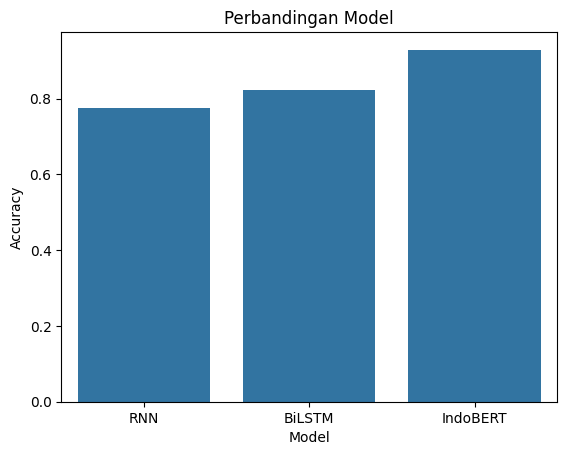

In [28]:
results = pd.DataFrame({
    'Model': ['RNN', 'BiLSTM', 'IndoBERT'],
    'Accuracy': [rnn_acc, bilstm_acc, bert_acc]
})

print(results)

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Perbandingan Model")
plt.show()

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name, label_names):
    print(f"\n===== {model_name} =====")

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    # Precision, Recall, F1 (macro)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc, precision, recall, f1
# A small change to ensure re-execution of this function definition cell.


===== RNN =====
Accuracy: 0.7740585774058577
Precision: 0.7084561012924047
Recall: 0.7240143738677286
F1-Score: 0.7113364690781356

Classification Report:
              precision    recall  f1-score   support

      kritik       0.84      0.69      0.76       131
      netral       0.86      0.93      0.89       160
  pertanyaan       0.70      0.75      0.73       114
      pujian       0.69      0.63      0.66        52
       saran       0.45      0.62      0.52        21

    accuracy                           0.77       478
   macro avg       0.71      0.72      0.71       478
weighted avg       0.78      0.77      0.77       478



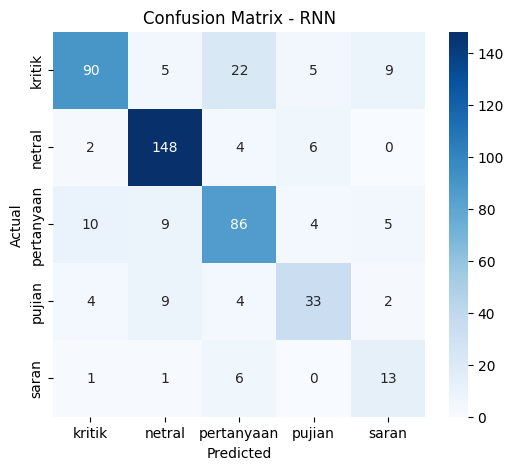

In [30]:
rnn_metrics = evaluate_model(
    y_test,
    rnn_pred,
    "RNN",
    le.classes_
)


===== BiLSTM =====
Accuracy: 0.8221757322175732
Precision: 0.8392603077816492
Recall: 0.6727179295861497
F1-Score: 0.6892231224073825

Classification Report:
              precision    recall  f1-score   support

      kritik       0.83      0.81      0.82       131
      netral       0.86      0.97      0.91       160
  pertanyaan       0.80      0.86      0.83       114
      pujian       0.71      0.58      0.64        52
       saran       1.00      0.14      0.25        21

    accuracy                           0.82       478
   macro avg       0.84      0.67      0.69       478
weighted avg       0.83      0.82      0.81       478



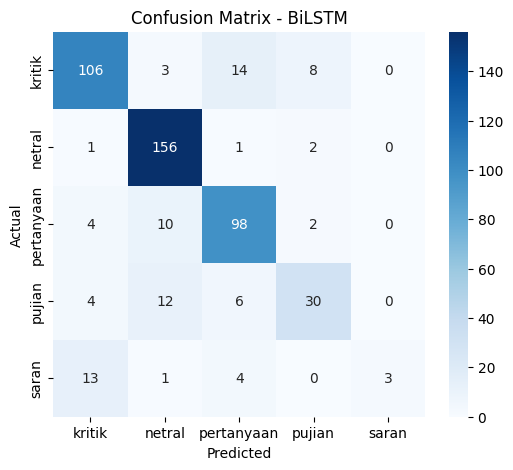

In [31]:
bilstm_metrics = evaluate_model(
    y_test,
    bilstm_pred,
    "BiLSTM",
    le.classes_
)


===== IndoBERT =====
Accuracy: 0.9288702928870293
Precision: 0.8915814902040372
Recall: 0.8781496680632881
F1-Score: 0.8841468745347439

Classification Report:
              precision    recall  f1-score   support

      kritik       0.95      0.94      0.94       131
      netral       0.93      0.97      0.95       160
  pertanyaan       0.97      0.96      0.97       114
      pujian       0.85      0.75      0.80        52
       saran       0.76      0.76      0.76        21

    accuracy                           0.93       478
   macro avg       0.89      0.88      0.88       478
weighted avg       0.93      0.93      0.93       478



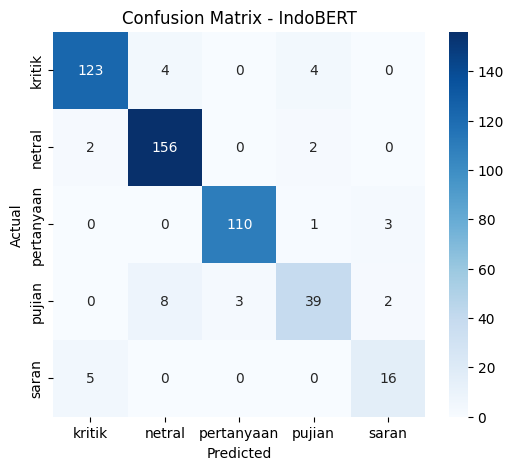

In [32]:
bert_metrics = evaluate_model(
    y_test,
    bert_preds,
    "IndoBERT",
    le.classes_
)

In [33]:
results = pd.DataFrame({
    'Model': ['RNN', 'BiLSTM', 'IndoBERT'],
    'Accuracy': [rnn_metrics[0], bilstm_metrics[0], bert_metrics[0]],
    'Precision': [rnn_metrics[1], bilstm_metrics[1], bert_metrics[1]],
    'Recall': [rnn_metrics[2], bilstm_metrics[2], bert_metrics[2]],
    'F1-Score': [rnn_metrics[3], bilstm_metrics[3], bert_metrics[3]]
})

print(results)

      Model  Accuracy  Precision    Recall  F1-Score
0       RNN  0.774059   0.708456  0.724014  0.711336
1    BiLSTM  0.822176   0.839260  0.672718  0.689223
2  IndoBERT  0.928870   0.891581  0.878150  0.884147


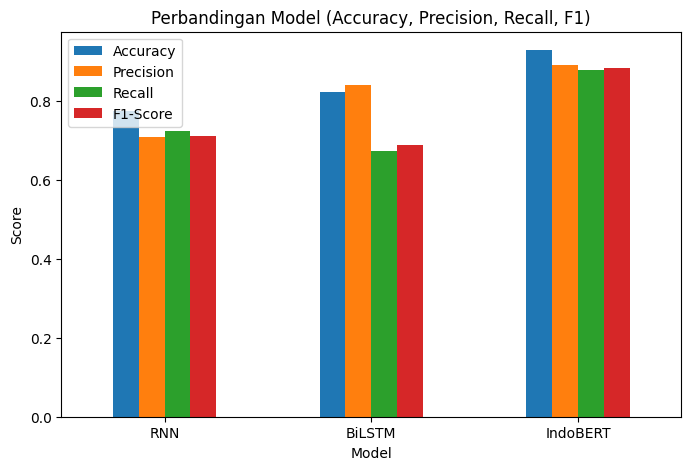

In [34]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Model (Accuracy, Precision, Recall, F1)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [39]:
bert_model.save_pretrained("indobert_model")
tokenizer_bert.save_pretrained("indobert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('indobert_model/tokenizer_config.json', 'indobert_model/tokenizer.json')

In [40]:
!zip -r indobert_model.zip indobert_model

  adding: indobert_model/ (stored 0%)
  adding: indobert_model/model.safetensors (deflated 7%)
  adding: indobert_model/tokenizer.json (deflated 71%)
  adding: indobert_model/config.json (deflated 58%)
  adding: indobert_model/tokenizer_config.json (deflated 42%)
